# 1.3 Convolutions

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from scipy import signal
import torch.nn.functional as F

import torch
from torch import nn

## Convolutions of functions

A convolution is a mathematical operations that receives as **input two functions** and produces as **output another function**.

The intuition is that one input function **sweeps over** the second input function and they get multiplied along the way.

See [Wikipedia:Convolution](https://en.wikipedia.org/wiki/Convolution)

$$(f*g)(t) = \int_{-\infty}^\infty f(t)g(t-\tau)d\tau$$

In [5]:
f = lambda x: ((x>1) & (x<2)).astype(int)
g = lambda x: ((x>1) & (x<2)).astype(int)

x = np.linspace(-1,4,1000)
c = np.convolve(f(x),g(x), "same")
c = c/np.max(c)

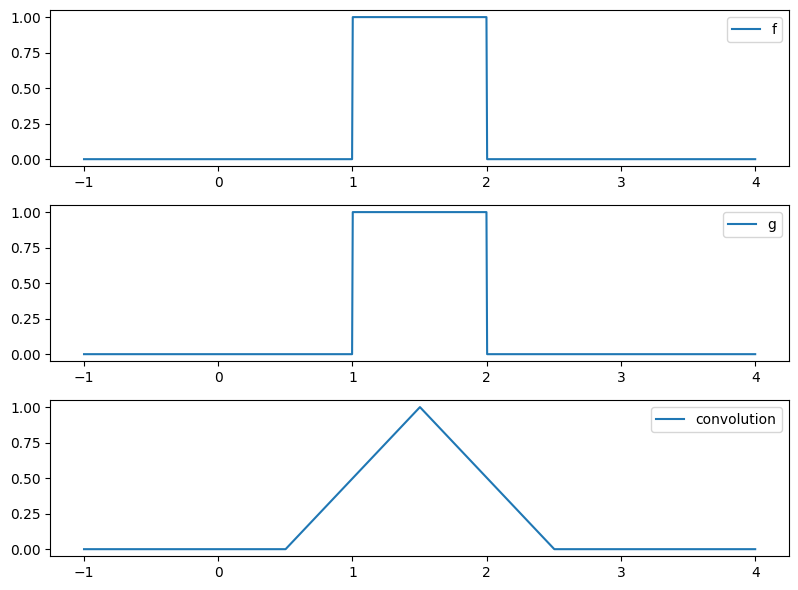

In [6]:
plt.figure(figsize=(8,6))
plt.subplot(311); plt.plot(x,f(x), label="f"); plt.legend()
plt.subplot(312); plt.plot(x,g(x), label="g"); plt.legend()
plt.subplot(313); plt.plot(x,c, label="convolution"); plt.legend()
plt.tight_layout()

## Convolution is just multiplication and adding

In a discrete setting, integration becomes summation.

$$(f*g)[t] = \sum_{i=-\infty}^{+\infty} f[t]g[t-i]$$

In [7]:
a = np.r_[0,0,1,1,1,0,0]
b = np.r_[0,0,1,1,1,0,0]
np.convolve(a,b)

array([0, 0, 0, 0, 1, 2, 3, 2, 1, 0, 0, 0, 0])

observe each convolution step is just an element by element multiplication of vectors and a sumation of the resulting elements.

In [8]:
for i in range(len(a)*2-1):
    pa, pb = (a[:i+1], b[-i-1:]) if i < len(a) else (a[i-len(a)+1:], b[:-(i-len(a))-1])
    print ((pa*pb).sum(), "=", pa, "*", pb)

0 = [0] * [0]
0 = [0 0] * [0 0]
0 = [0 0 1] * [1 0 0]
0 = [0 0 1 1] * [1 1 0 0]
1 = [0 0 1 1 1] * [1 1 1 0 0]
2 = [0 0 1 1 1 0] * [0 1 1 1 0 0]
3 = [0 0 1 1 1 0 0] * [0 0 1 1 1 0 0]
2 = [0 1 1 1 0 0] * [0 0 1 1 1 0]
1 = [1 1 1 0 0] * [0 0 1 1 1]
0 = [1 1 0 0] * [0 0 1 1]
0 = [1 0 0] * [0 0 1]
0 = [0 0] * [0 0]
0 = [0] * [0]


the `mode` argument to convolve regulates `padding`


In [10]:
np.convolve(a,b, mode="same")

array([0, 1, 2, 3, 2, 1, 0])

Of course, the functions can have any values, and not necessarily be the same, and we assume there is infinity zero padding on both arguments, so they **do not have to be the same size**.

In this case:

- `a` is considered the **source signal**
- `b` is considered the **filter**

In [11]:
a = np.r_[0,0,1,1,1,0,0]
b = np.r_[1,0,1]
np.convolve(a,b)

array([0, 0, 1, 1, 2, 1, 1, 0, 0])

## Convolution with images

It is simply sweeping in both directions 


In [13]:
img = imread("local/imgs/cars-driving.jpg").mean(axis=2)
img = (img-np.min(img))/(np.max(img)-np.min(img)) # normalize to 0,1
img.shape, np.min(img), np.max(img)

((278, 493), np.float64(0.0), np.float64(1.0))

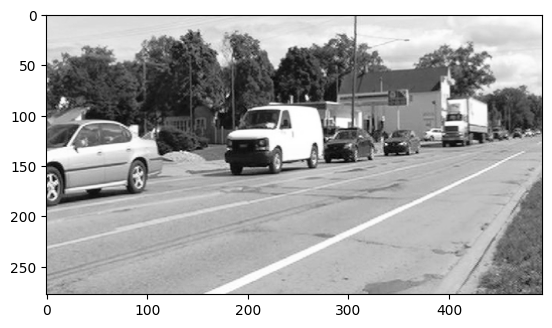

In [14]:
plt.imshow(img, cmap=plt.cm.Greys_r)

a conv 2D is just the same element by element multiplication and summation.


In [15]:
f1 = np.r_[[[-1,-1], [1,1]]]
print (f1)
c1 = signal.convolve2d(img, f1, mode="valid")

[[-1 -1]
 [ 1  1]]


and this filter has a border detection effect.

In [16]:
c1[0,1], (img[:2,:2]*f1).sum()

(np.float64(1.1102230246251565e-16), np.float64(1.1102230246251565e-16))

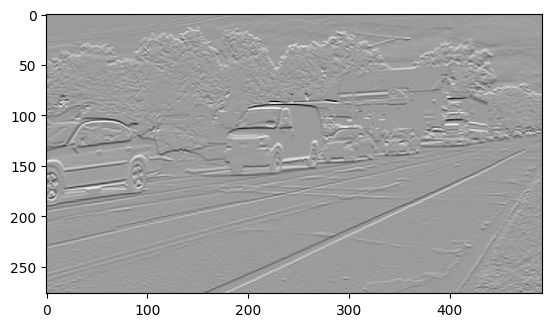

In [17]:
plt.imshow(c1, cmap=plt.cm.Greys_r)

 We use `abs` con convert all differences into positive, since we do not care the *direction* of edges.

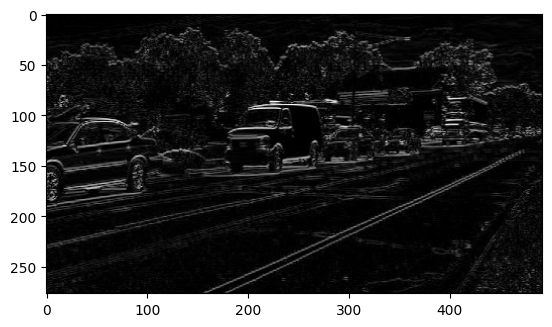

In [18]:
plt.imshow(np.abs(c1), cmap=plt.cm.Greys_r)

and a filter for vertical edge detection


<function <lambda> at 0x7f324e6b2d40>


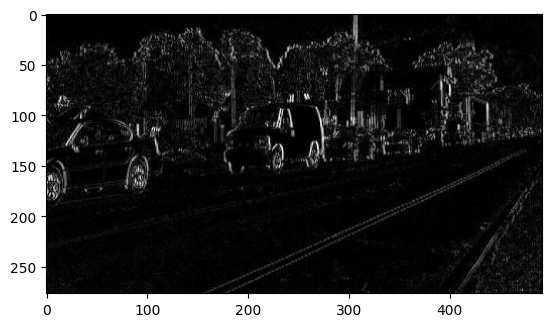

In [19]:
f2 = np.r_[[[1,-1], [1,-1]]]
print(f)
c2 = signal.convolve2d(img, f2, mode="valid")
plt.imshow(np.abs(c2), cmap=plt.cm.Greys_r)

combining both outputs

[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


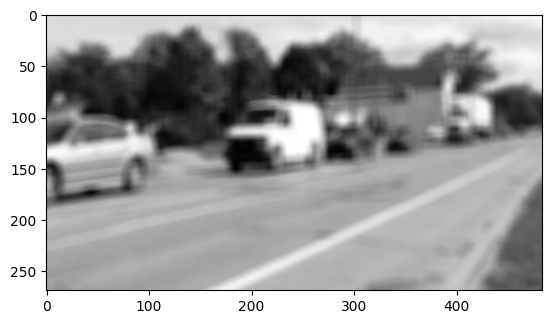

In [21]:
f = np.ones((10,10))
print(f)
c = signal.convolve2d(img, f, mode="valid")
plt.imshow(np.abs(c), cmap=plt.cm.Greys_r)

## In Pytorch in just the same

`pytorch` usually expects an array of imgs of shape

    (n_imgs, n_channels, pixels_width, pixels_height)

**observer** channels go first

In [30]:
# reshape image
img = imread("local/imgs/cars-driving.jpg").mean(axis=2)
img = (img-np.min(img))/(np.max(img)-np.min(img)) # normalize to 0,1
img = img.reshape(1,*img.shape,1)
img = np.transpose(img, (0,3,1,2))
img.shape


(1, 1, 278, 493)

In [32]:
timg = torch.Tensor(img)

In [52]:
c = nn.Conv2d(
    in_channels=1,    # e.g., RGB channels
    out_channels=1,   # Number of filters (features to detect)
    kernel_size=2,    # A 2x2 sliding window
    stride=1,         # Move 1 pixel at a time
    padding=1       # Add a 1-pixel border so output size equals input size
)

In [53]:
for w in c.parameters():
    print (w.shape)

torch.Size([1, 1, 2, 2])
torch.Size([1])


In [51]:
c(timg).shape

torch.Size([1, 1, 277, 492])

In [ ]:
c.set_weights([ np.r_[[[-1,-1], [1,1]]].reshape(2,2,1,1), np.r_[0]])

In [54]:
f2

array([[ 1, -1],
       [ 1, -1]])

In [67]:
with torch.no_grad():
    c.weight.copy_(torch.Tensor( np.r_[[[-1,-1], [1,1]]].reshape(1,1,2,2)))
    c.bias.fill_(0.0) # Reset bias to zero

In [68]:
o = c(timg)
o.shape

torch.Size([1, 1, 279, 494])

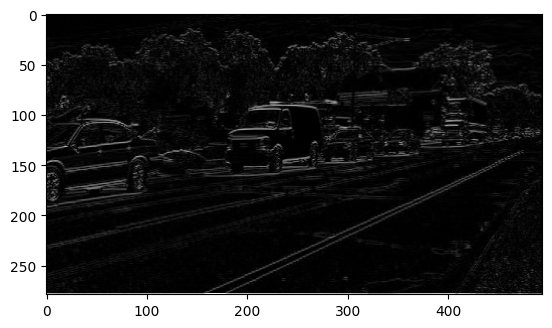

In [79]:
plt.imshow(np.abs(o[0,0].detach().numpy()), cmap=plt.cm.Greys_r)

activations are simply applied to the output. Observe how a `relu` activation with an horizontal edge detection filter detects edges in **one direction**

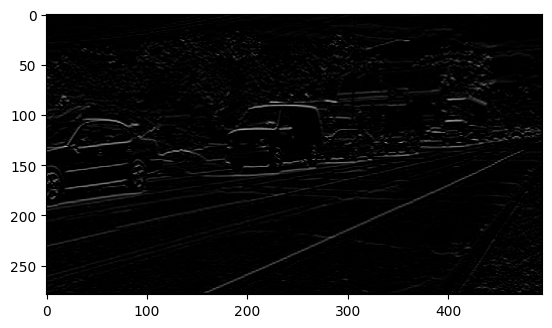

In [82]:
o = F.relu(c(timg))
plt.imshow(np.abs(o[0,0].detach().numpy()), cmap=plt.cm.Greys_r)

for color images, filters also have to have three channels


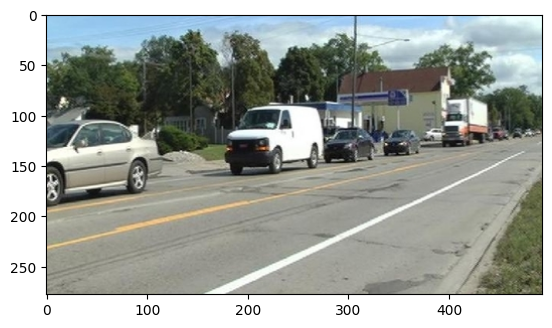

In [83]:
img = imread("local/imgs/cars-driving.jpg")
img = (img-np.min(img))/(np.max(img)-np.min(img)) # normalize to 0,1
img = img.reshape(1, *img.shape)
plt.imshow(img[0])

In [121]:
f = -np.ones((3,3,3))*3
f[0,:,:] = 3
f

array([[[ 3.,  3.,  3.],
        [ 3.,  3.,  3.],
        [ 3.,  3.,  3.]],

       [[-3., -3., -3.],
        [-3., -3., -3.],
        [-3., -3., -3.]],

       [[-3., -3., -3.],
        [-3., -3., -3.],
        [-3., -3., -3.]]])

In [122]:
c = nn.Conv2d(
    in_channels=3,    # e.g., RGB channels
    out_channels=1,   # Number of filters (features to detect)
    kernel_size=3,    # A 2x2 sliding window
    stride=1,         # Move 1 pixel at a time
    padding=1       # Add a 1-pixel border so output size equals input size
)

with torch.no_grad():
    c.weight.copy_(torch.Tensor(f).reshape(1,3,3,3))
    c.bias.fill_(0.0) # Reset bias to zero

In [123]:
timg = torch.Tensor(np.transpose(img, (0,3,1,2)))
cimg = F.sigmoid(c(timg))
cimg = cimg.detach().numpy()
cimg.shape

(1, 1, 278, 493)

observe how **very pure** red is detected (hand crafted filter is difficult to 

(np.float64(-0.5), np.float64(492.5), np.float64(277.5), np.float64(-0.5))

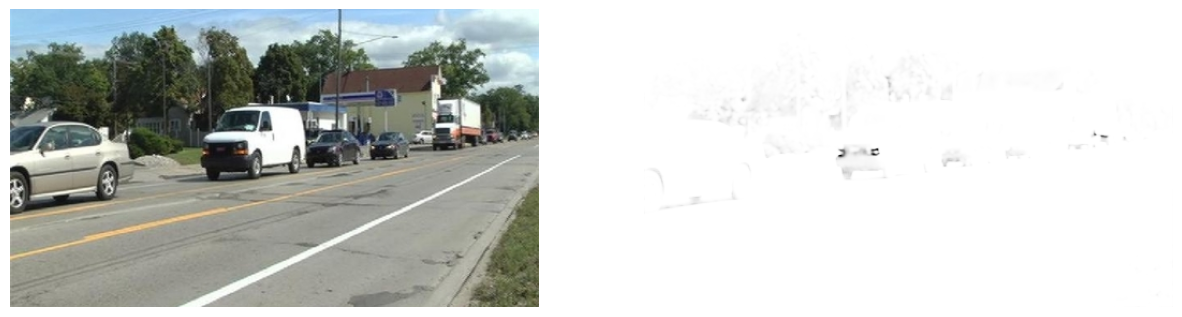

In [124]:
plt.figure(figsize=(15,10))
plt.subplot(121); plt.imshow(img[0,:,:]); plt.axis("off")
plt.subplot(122); plt.imshow(cimg[0,0,:,:,], cmap=plt.cm.Greys); plt.axis("off")

detect green (little)


(np.float64(-0.5), np.float64(492.5), np.float64(277.5), np.float64(-0.5))

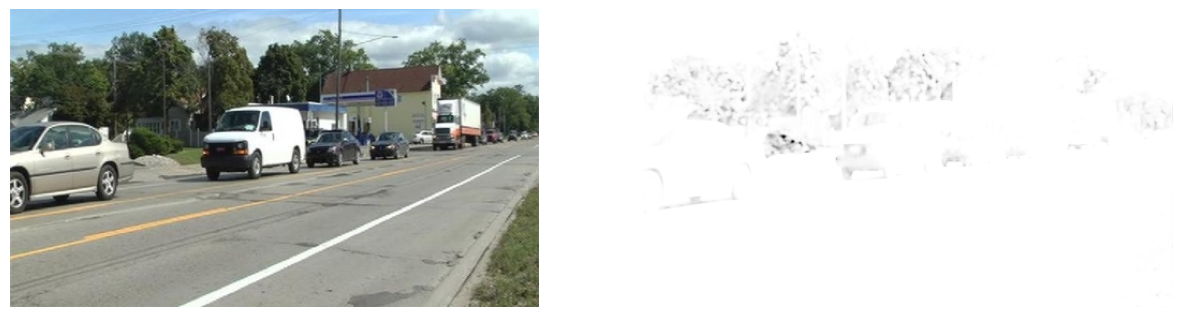

In [120]:
f = -np.ones((3,3,3))*3
f[1,:,:] = 3
with torch.no_grad():
    c.weight.copy_(torch.Tensor(f).reshape(1,3,3,3))
    c.bias.fill_(0.0) # Reset bias to zero
    
timg = torch.Tensor(np.transpose(img, (0,3,1,2)))
cimg = F.sigmoid(c(timg))
cimg = cimg.detach().numpy()


plt.figure(figsize=(15,10))
plt.subplot(121); plt.imshow(img[0,:,:]); plt.axis("off")
plt.subplot(122); plt.imshow(cimg[0,0,:,:,], cmap=plt.cm.Greys); plt.axis("off")